# GNN 침수예측 학습셋 가용성 진단 (관악구 타겟)

**원 목표**: 관악구 배수지역 침수 예측 GNN. 관악 데이터가 부족해 서울 전역으로 확장했음.
**질문**: 지금 데이터로 GNN 학습셋 정제가 가능한가? 불가능하면 어떤 데이터가 필요한가?

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
import sys; sys.path.insert(0,'/home/namjun/city_flood/scripts'); from krfont import set_korean; set_korean()
EB="dataset/processed/eda_based/"
rn=pd.read_parquet("dataset/processed/cleaned/road_node.parquet",columns=['sensor_id','자치구'])
sn=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id','자치구'])
trust=pd.read_parquet(EB+"road_flood_sensor_trust.parquet")
au=pd.read_parquet(EB+"sewer_surcharge_audit.parquet")
rp=pd.read_parquet(EB+"road_panel_10min.parquet",columns=['sensor_id','ts10','flood_t6'])
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",columns=['sewer_sensor_id','ts10','fill_rate'])

## 1. 관악구 단독 — supervised 학습 가능한가?

In [2]:
gw_road=rn[rn.자치구=='관악구청'].sensor_id; gw_sew=sn[sn.자치구=='관악구'].sensor_id
print("관악 도로센서:",len(gw_road),"| 진짜상습:",
      (trust[trust.sensor_id.isin(gw_road)].판정_final=='진짜상습').sum(),"(조원로5-6 1개)")
g=sf[sf.sewer_sensor_id.isin(gw_sew)]
print("관악 하수센서:",len(gw_sew),"| 만관(fill>=1) 총건수:",int((g.fill_rate>=1).sum()),"| fill 최대:",round(g.fill_rate.max(),2))
# 반례: 조원로 침수시각 관악하수 fill
jw=rp[(rp.sensor_id=='조원로 5-6')&(rp.flood_t6==1)][['ts10']]
mg=jw.merge(g.groupby('ts10').fill_rate.max().rename('fill'),on='ts10',how='left')
print(f"★반례: 조원로5-6 도로침수 {len(jw)}회 시각의 관악하수 최대fill 평균 {mg.fill.mean():.2f} = 도로 침수해도 하수관은 13%만 참")

관악 도로센서: 5 | 진짜상습: 1 (조원로5-6 1개)


관악 하수센서: 13 | 만관(fill>=1) 총건수: 0 | fill 최대: 0.92
★반례: 조원로5-6 도로침수 30회 시각의 관악하수 최대fill 평균 0.13 = 도로 침수해도 하수관은 13%만 참


## 2. 서울 전역으로 넓혀도 — GNN 공간학습이 성립하나?

In [3]:
tr=trust[trust.판정_final=='진짜상습'].merge(rn,on='sensor_id',how='left')
conf=au[au.최종판정.str.startswith('확정')].sewer_sensor_id.tolist()
sw=pd.DataFrame({'sensor_id':conf}).merge(sn,on='sensor_id',how='left')
print("진짜상습 도로 10센서 자치구:",tr.자치구.value_counts().to_dict())
print("확정만관 하수  5센서 자치구:",sw.자치구.value_counts().to_dict())
print("→ 진짜 신호가 구마다 1개씩 흩어짐. 도로·하수가 같은 곳에 공존하는 자치구 = 금천(시흥동) 1곳뿐")
print("도로↔하수 차분상관(기존 결론) ~0.05 = 그래프 엣지로 전파시킬 신호 약함")

진짜상습 도로 10센서 자치구: {'은평구청': 1, '광진구청': 1, '금천구청': 1, '관악구청': 1, '종로구청': 1, '영등포구청': 1, '강남구청': 1, '서대문구청': 1}
확정만관 하수  5센서 자치구: {'동대문구': 1, '노원구': 1, '강서구': 1, '금천구': 1, '동작구': 1}
→ 진짜 신호가 구마다 1개씩 흩어짐. 도로·하수가 같은 곳에 공존하는 자치구 = 금천(시흥동) 1곳뿐
도로↔하수 차분상관(기존 결론) ~0.05 = 그래프 엣지로 전파시킬 신호 약함


## 3. 종합 시각화

/tmp/ipykernel_144587/1268278684.py:19: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/06_gnn_feasibility.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykernel_144587/1268278684.py:19: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/06_gnn_feasibility.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykernel_144587/1268278684.py:19: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/06_gnn_feasibility.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykernel_144587/1268278684.py:19: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/06_gnn_feasibility.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykern

/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL S

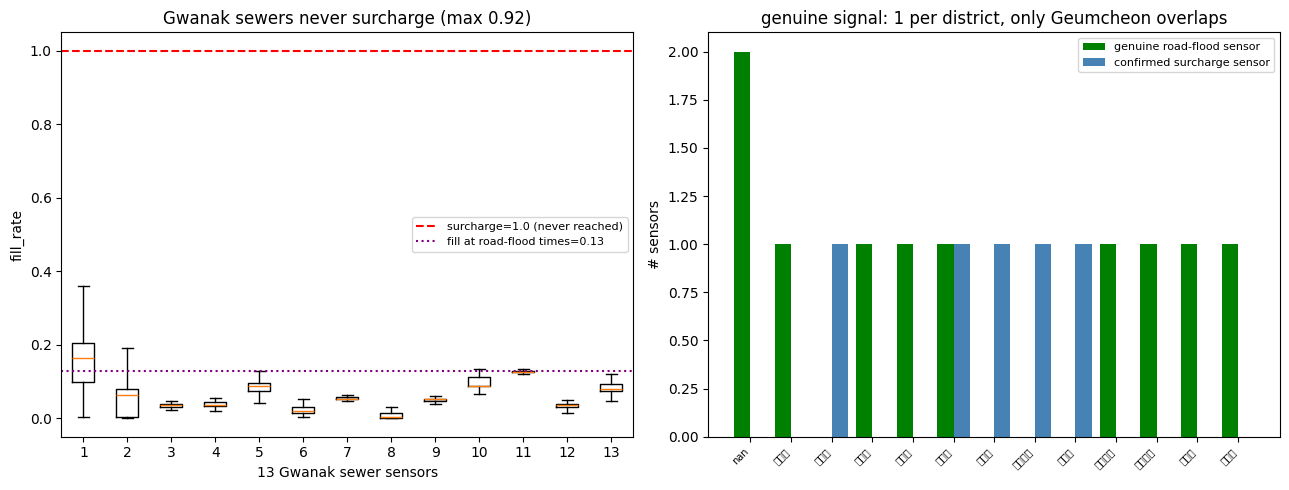

saved


In [4]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
# (A) 관악 하수는 호우에도 안 참 + 도로침수시 하수 낮음
gg=sf[sf.sewer_sensor_id.isin(gw_sew)]
ax[0].boxplot([gg[gg.sewer_sensor_id==s].fill_rate.values for s in gw_sew],vert=True,showfliers=False)
ax[0].axhline(1,ls='--',c='r',label='만관=1.0 (도달 못함)')
ax[0].axhline(mg.fill.mean(),ls=':',c='purple',label=f'fill at road-flood times={mg.fill.mean():.2f}')
ax[0].set_title('관악 하수는 만관 없음 (최대 0.92)'); ax[0].set_ylabel('충전율'); ax[0].set_xlabel('관악 하수 13센서'); ax[0].legend(fontsize=8)
# (B) 자치구별 진짜신호 카운트
gus=sorted(set(tr.자치구.dropna())|set(sw.자치구.dropna()+'청'))
import re
def norm(x): return str(x).replace('청','')
roadc=tr.자치구.apply(norm).value_counts(); sewc=sw.자치구.apply(norm).value_counts()
allg=sorted(set(roadc.index)|set(sewc.index))
x=np.arange(len(allg))
ax[1].bar(x-0.2,[roadc.get(g,0) for g in allg],0.4,label='진짜 도로침수 센서',color='green')
ax[1].bar(x+0.2,[sewc.get(g,0) for g in allg],0.4,label='확정 만관 센서',color='steelblue')
ax[1].set_xticks(x); ax[1].set_xticklabels(allg,rotation=45,ha='right',fontsize=7)
ax[1].set_title('진짜신호: 구마다 1개, 금천만 공존'); ax[1].legend(fontsize=8); ax[1].set_ylabel('센서 수')
plt.tight_layout(); plt.savefig('reports/figures_sewer/06_gnn_feasibility.png',dpi=110,bbox_inches='tight'); plt.show()
print('saved')

## 결론 — 현재 데이터로 GNN 침수예측 학습셋은 **구축 불가**

**왜:**
1. **관악 단독 불가**: 진짜 침수센서 1개(조원로5-6), 하수 만관 0건. 도로 침수해도 하수 fill 0.13 = 가설(만관원인)이 관악엔 관측 안 됨(표면류형 침수 추정).
2. **서울로 넓혀도 GNN 부적합**: 진짜 신호가 구마다 1개씩 흩어지고(공존=금천 1곳), 도로↔하수 결합 0.05 → GNN의 핵심인 *공간 전파 학습*이 성립할 dense subgraph 부재. 양성 라벨 0.42%·93% 아티팩트.
3. **유일한 dense 사슬은 시흥동 1쌍** → 단일/소수지점 모델은 되나 그래프 모델은 표본부족.

**대안 경로(GNN을 살리려면)**: 희소한 *도로침수 라벨* 대신 **하수 관망에서 수위/만관을 예측하는 GNN**이 현실적 —
484노드·연속수위(78% A등급)·실제 관 토폴로지·강우구동(corr0.21). 단 **관 흐름방향 토폴로지(관망 GIS)** 가 있어야 엣지가 물리적이 됨(현재 엣지는 근접·배수구역 기반).

→ 필요 데이터는 다음 셀 표 참조.

In [5]:
need=pd.DataFrame([
 ['① 독립 침수 정답','센서 라벨 93% 아티팩트, 양성 0.42%','서울시 침수흔적도 GIS, 120/119 침수신고, 침수 CCTV, 재해연보','최우선'],
 ['② 다년 침수 이력','진짜양성 ~1549bin·소수 호우일; 도로센서 2024~만','2020·2022 대홍수 포함 다년 여름 수위·침수기록','최우선'],
 ['③ 관망 토폴로지 GIS','엣지가 근접기반(흐름방향X), 하수GNN 물리근거 없음','우수/오수 관거 노드-엣지(흐름방향), 배수구역 경계','높음(하수GNN 핵심)'],
 ['④ 저지대 DEM·우수유입구','관악=표면류형 추정(하수 안참)','수치표고(DEM), 빗물받이/유입구 위치','중간'],
 ['⑤ 레이더 강우','AWS 1.5km 공백, 국지호우 누락','기상청 레이더 강우(HSR) 또는 조밀 AWS','중간'],
],columns=['필요 데이터','현재 병목(증거)','구체 소스','우선순위'])
need.to_parquet(EB+"gnn_data_needs.parquet",index=False)
print(need.to_string(index=False))

         필요 데이터                         현재 병목(증거)                                      구체 소스         우선순위
     ① 독립 침수 정답          센서 라벨 93% 아티팩트, 양성 0.42% 서울시 침수흔적도 GIS, 120/119 침수신고, 침수 CCTV, 재해연보          최우선
     ② 다년 침수 이력 진짜양성 ~1549bin·소수 호우일; 도로센서 2024~만             2020·2022 대홍수 포함 다년 여름 수위·침수기록          최우선
  ③ 관망 토폴로지 GIS    엣지가 근접기반(흐름방향X), 하수GNN 물리근거 없음              우수/오수 관거 노드-엣지(흐름방향), 배수구역 경계 높음(하수GNN 핵심)
④ 저지대 DEM·우수유입구                 관악=표면류형 추정(하수 안참)                     수치표고(DEM), 빗물받이/유입구 위치           중간
       ⑤ 레이더 강우             AWS 1.5km 공백, 국지호우 누락                  기상청 레이더 강우(HSR) 또는 조밀 AWS           중간
